# Chapter 13: Signal Processing and Optimization

**Source span:** printed pages 315-358; PDF pages 318-361. I inspected the assigned PDF span for chapter order, terminology, and formula orientation only. This notebook uses original prose, generated data, generated figures, and executable checks; it does not copy textbook prose, exercises, screenshots, page crops, or figures.

## Chapter Goal

The chapter's applications look different on the surface: principal components, independent components, non-negative factors, sparse regression paths, interior-point barriers, and scoring rules. The common geometry is that each method chooses coordinates, constraints, or scores that make hidden structure visible. This notebook turns those choices into inspectable objects and then checks the invariants that make each picture trustworthy.

## Computational Translation Guide

- **PCA and whitening** become covariance geometry: eigenvectors are axes of a metric ellipse, whitening turns that ellipse into a unit circle, and online learning follows a path on the unit sphere.
- **ICA** begins where PCA stops: after whitening, the remaining ambiguity is a rotation. Non-Gaussian score geometry chooses a rotation; Gaussian sources expose the failure mode because rotations are not identifiable.
- **NMF** is constrained factor geometry: data, basis rays, and coefficients stay in the non-negative cone, so a factorization should never require negative parts.
- **Sparse signal processing** is optimization over an `L1` diamond. The solution path is a constrained metric projection, not a Euclidean radial shrinkage.
- **Barrier programming** turns a feasible region into a dually flat geometry. The central path curves in primal coordinates but is straight in the barrier-gradient coordinates.
- **Game scores and the Hyvarinen score** replace likelihood normalization with derivative information. The score identity is checked directly so the visual surface is tied to a proper divergence claim.


In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots


def find_book_root(start: Path) -> Path:
    """Find the Information Geometry course root from notebook or repo execution."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").exists() and (candidate / "utils").exists():
            return candidate
    for candidate in candidates:
        nested = candidate / "Information-Geometry-and-Its-Applications"
        if (nested / "AGENTS.md").exists() and (nested / "artifacts").exists() and (nested / "utils").exists():
            return nested
    raise RuntimeError("Could not locate Information-Geometry-and-Its-Applications book root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_record, display_artifact, save_json, save_matplotlib, save_plotly_html

TOPIC = "chapter-13"
SOURCE_SPAN = "printed pages 315-358; PDF pages 318-361"
rng = np.random.default_rng(202613)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


## Visual Storyboard And Library Routing

The visual plan is intentionally small and inspectable. Matplotlib is used for durable 2D geometry: covariance ellipses, cones, diamonds, paths, score contours, and invariant diagnostics. Plotly is used for the barrier surface because rotating the surface and central path helps reveal how the boundary shapes the metric. NumPy carries the linear algebra, moment, projection, factorization, and score checks. No source page images or textbook figures are used.


In [2]:
storyboard = {
    "chapter_goal": "Make signal-processing and optimization geometry visible through covariance axes, demixing rotations, positive cones, sparse L1 paths, barrier dual coordinates, and score identities.",
    "source_span_read": {
        "printed_pages": "315-358",
        "pdf_pages": "318-361",
        "source_pdf": "Information-Geometry-and-Its-Applications/Information Geometry and Its Applications.pdf",
        "used_for": "orientation on section order, terminology, formulas, and concept boundaries only",
    },
    "library_routing": [
        {"concept": "PCA, minor components, and whitening", "representation": "covariance ellipse, whitened cloud, online eigenvector path", "library": "NumPy + Matplotlib", "why": "the geometry is a 2D SPD covariance and a unit-sphere learning path"},
        {"concept": "ICA as non-Gaussian rotation after whitening", "representation": "mixed, whitened, contrast-vs-rotation, recovered scatter", "library": "NumPy + Matplotlib", "why": "2D whitening reduces demixing to an inspectable rotation and moment contrast"},
        {"concept": "NMF positive factor geometry", "representation": "non-negative cone, learned rays, activation heatmap, residual curve", "library": "NumPy + Matplotlib", "why": "multiplicative updates expose the constraint without an opaque optimizer"},
        {"concept": "sparse L1 solution path", "representation": "quadratic contours, L1 diamonds, exact polygon projection path", "library": "NumPy + Matplotlib", "why": "the diamond boundary and metric projection are planar geometric objects"},
        {"concept": "barrier-induced dual geometry", "representation": "interactive barrier surface with central path and dual straight line", "library": "Plotly + NumPy", "why": "3D rotation clarifies boundary blow-up while the dual path is read in a linked panel"},
        {"concept": "game-score and Hyvarinen score geometry", "representation": "score divergence contours and score-field identity", "library": "NumPy + Matplotlib", "why": "the derivative-based score identity is a numerical integral and contour check"},
    ],
    "visual_sequence": [
        {"artifact": "figures/pca-whitening-learning-geometry.png", "inspection_target": "PCA axes diagonalize covariance; whitening removes covariance scale; Oja updates approach the first principal axis", "validation": "orthonormal eigenvectors, identity whitened covariance, inverse covariance selects the minor axis, small final Oja angle"},
        {"artifact": "figures/ica-score-demixing-geometry.png", "inspection_target": "PCA decorrelates but does not identify independent non-Gaussian axes; a rotation contrast does", "validation": "whitening identity covariance, high recovered-source correlations, Gaussian contrast nearly flat"},
        {"artifact": "figures/nmf-positive-factor-geometry.png", "inspection_target": "NMF explains positive observations by positive rays and positive activations", "validation": "non-negative factors, decreasing Frobenius residual, ray alignment"},
        {"artifact": "figures/sparse-l1-solution-path-geometry.png", "inspection_target": "the sparse path follows the L1 boundary and differs from radial Euclidean shrinkage", "validation": "L1 feasibility, monotone objective, radial path suboptimality"},
        {"artifact": "html/barrier-dual-central-path.html", "inspection_target": "barrier blow-up bends the primal central path while gradient coordinates form a line", "validation": "positive slacks, positive Hessian eigenvalues, small dual residual"},
        {"artifact": "figures/game-score-hyvarinen-geometry.png", "inspection_target": "Hyvarinen score uses score fields and ignores normalization constants", "validation": "nonnegative divergence, score-identity residual, grid optimum near true parameters"},
    ],
    "artifact_plan": {
        "figures": ["pca-whitening-learning-geometry.png", "ica-score-demixing-geometry.png", "nmf-positive-factor-geometry.png", "sparse-l1-solution-path-geometry.png", "game-score-hyvarinen-geometry.png"],
        "html": ["barrier-dual-central-path.html"],
        "checks": ["chapter-13-visual-storyboard.json", "chapter-13-core-invariants.json", "signal-processing-and-optimization-sanity-summary.json", "final-sanity.json"],
    },
    "risks": [
        "ICA is identifiable only up to permutation and scale, so checks use absolute matched correlations.",
        "NMF is non-unique up to scaling/permutation, so checks use cone/ray alignment and reconstruction rather than exact factor equality.",
        "The barrier example uses a square so the dual path and Hessian can be checked explicitly.",
    ],
}
storyboard_path = save_json(storyboard, TOPIC, "checks", "chapter-13-visual-storyboard.json")
display_artifact(storyboard_path)


## 1. PCA, Whitening, And Online Principal-Axis Learning

PCA starts with second-order geometry. A covariance matrix draws an ellipse; its eigenvectors give the principal and minor directions, and its eigenvalues give the squared axis lengths. Whitening deliberately removes that metric scale. The same cloud then has identity covariance, which is useful before ICA but also dangerous: after whitening, every orthogonal rotation still has the same covariance.

The fourth panel shows an online eigenvector update. Its state is constrained to the unit circle, so the algorithm is a trajectory on a manifold, not an unconstrained Euclidean drift.


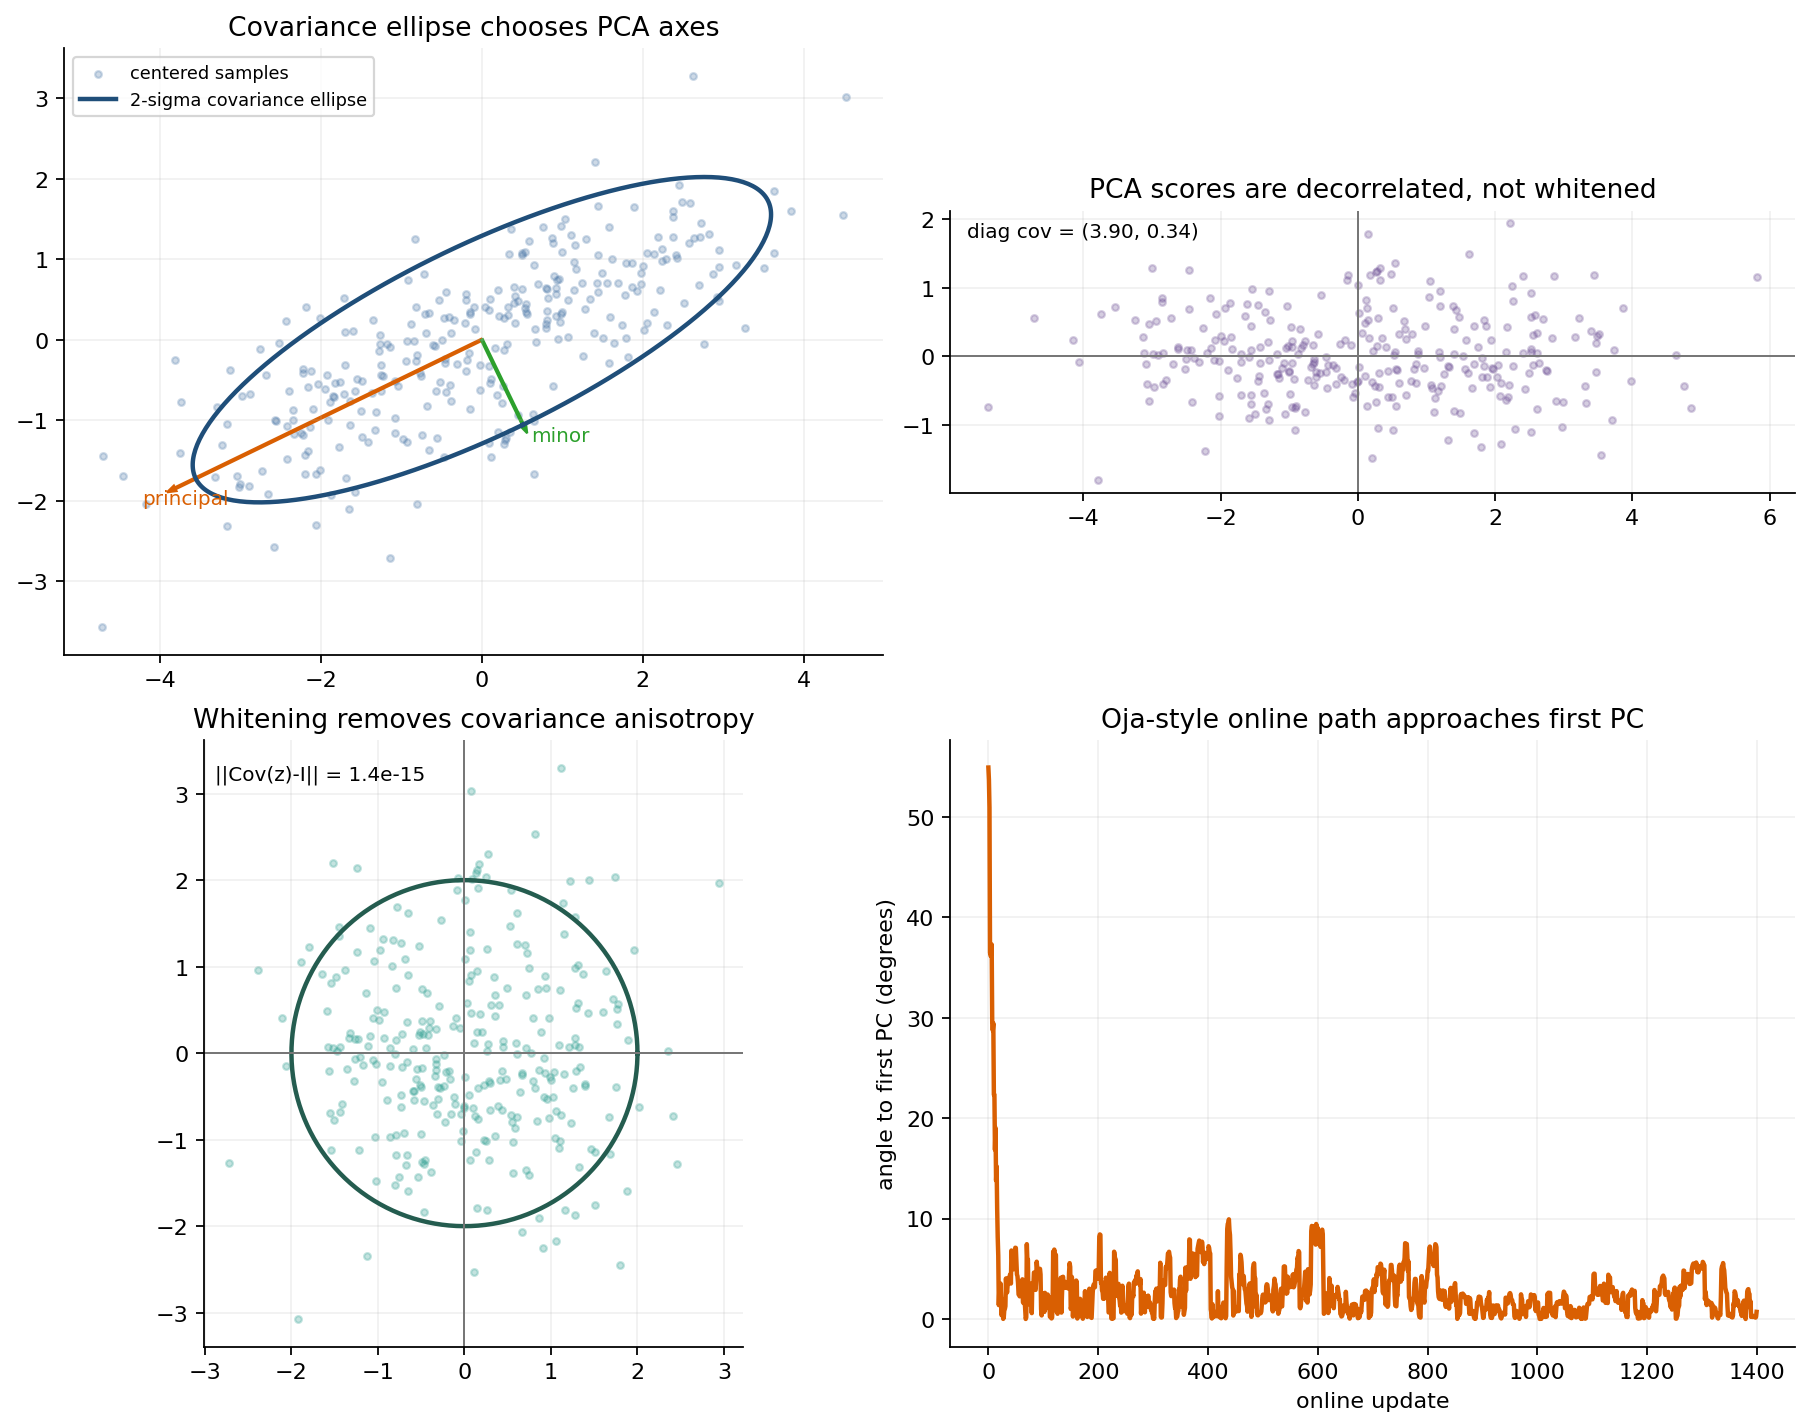

{'eigenvectors_orthonormal': True,
 'whitened_covariance_error': 1.4214751954541212e-15,
 'whitener_identity_error': 5.533272011671225e-16,
 'inverse_covariance_principal_is_original_minor': True,
 'oja_final_angle_degrees': 0.7074455661190131,
 'retained_one_component_variance_ratio': 0.918920884764051}

In [3]:
def empirical_cov(samples: np.ndarray) -> np.ndarray:
    return samples.T @ samples / samples.shape[0]


def covariance_ellipse(cov: np.ndarray, center: np.ndarray | None = None, radius: float = 2.0, samples: int = 300) -> np.ndarray:
    center = np.zeros(2) if center is None else center
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0.0)
    circle = np.column_stack([np.cos(np.linspace(0, 2 * np.pi, samples)), np.sin(np.linspace(0, 2 * np.pi, samples))])
    return center + circle @ (vecs @ np.diag(np.sqrt(vals) * radius)).T


target_cov = np.array([[3.2, 1.35], [1.35, 0.95]])
X_pca = rng.multivariate_normal(np.zeros(2), target_cov, size=900)
X_pca -= X_pca.mean(axis=0)
cov_hat = empirical_cov(X_pca)
vals_raw, vecs_raw = np.linalg.eigh(cov_hat)
order = np.argsort(vals_raw)[::-1]
eigvals = vals_raw[order]
eigvecs = vecs_raw[:, order]
principal_axis = eigvecs[:, 0]
minor_axis = eigvecs[:, -1]

scores = X_pca @ eigvecs
X_white = scores / np.sqrt(eigvals)
white_cov = empirical_cov(X_white)
whitener = np.diag(1 / np.sqrt(eigvals)) @ eigvecs.T

w = np.array([0.15, 0.99])
w /= np.linalg.norm(w)
angle_errors = []
for k in range(1400):
    xk = X_pca[k % X_pca.shape[0]]
    eta = 0.035 / (1.0 + k / 450.0)
    yk = float(w @ xk)
    w = w + eta * yk * (xk - yk * w)
    w /= np.linalg.norm(w)
    angle_errors.append(float(np.degrees(np.arccos(np.clip(abs(w @ principal_axis), -1.0, 1.0)))))
angle_errors = np.asarray(angle_errors)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0))
raw_step = 3
axes[0, 0].scatter(X_pca[::raw_step, 0], X_pca[::raw_step, 1], s=9, alpha=0.28, color="#4c78a8", label="centered samples")
ell = covariance_ellipse(cov_hat)
axes[0, 0].plot(ell[:, 0], ell[:, 1], color="#1f4e79", lw=2.0, label="2-sigma covariance ellipse")
for val, vec, color, name in zip(eigvals, eigvecs.T, ["#d95f02", "#2ca02c"], ["principal", "minor"]):
    length = math.sqrt(val) * 2.2
    axes[0, 0].arrow(0, 0, vec[0] * length, vec[1] * length, width=0.025, color=color, length_includes_head=True)
    axes[0, 0].text(vec[0] * length * 1.08, vec[1] * length * 1.08, name, color=color, fontsize=9)
axes[0, 0].set_title("Covariance ellipse chooses PCA axes")
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].legend(loc="upper left", fontsize=8)

axes[0, 1].scatter(scores[::raw_step, 0], scores[::raw_step, 1], s=9, alpha=0.28, color="#6a4c93")
axes[0, 1].axhline(0, color="#777777", lw=0.9)
axes[0, 1].axvline(0, color="#777777", lw=0.9)
axes[0, 1].set_title("PCA scores are decorrelated, not whitened")
axes[0, 1].set_aspect("equal", adjustable="box")
axes[0, 1].text(0.02, 0.96, f"diag cov = ({eigvals[0]:.2f}, {eigvals[1]:.2f})", transform=axes[0, 1].transAxes, va="top", fontsize=9)

axes[1, 0].scatter(X_white[::raw_step, 0], X_white[::raw_step, 1], s=9, alpha=0.28, color="#2a9d8f")
unit = covariance_ellipse(np.eye(2), radius=2.0)
axes[1, 0].plot(unit[:, 0], unit[:, 1], color="#245c4f", lw=2.0)
axes[1, 0].axhline(0, color="#777777", lw=0.9)
axes[1, 0].axvline(0, color="#777777", lw=0.9)
axes[1, 0].set_title("Whitening removes covariance anisotropy")
axes[1, 0].set_aspect("equal", adjustable="box")
axes[1, 0].text(0.02, 0.96, f"||Cov(z)-I|| = {np.linalg.norm(white_cov - np.eye(2)):.1e}", transform=axes[1, 0].transAxes, va="top", fontsize=9)

axes[1, 1].plot(angle_errors, color="#d95f02", lw=2.0)
axes[1, 1].set_title("Oja-style online path approaches first PC")
axes[1, 1].set_xlabel("online update")
axes[1, 1].set_ylabel("angle to first PC (degrees)")
axes[1, 1].grid(alpha=0.25)
for ax in axes.ravel():
    ax.grid(alpha=0.18)
fig.tight_layout()
pca_path = save_matplotlib(fig, TOPIC, "figures", "pca-whitening-learning-geometry.png")
plt.close(fig)
display_artifact(pca_path, width=920)

inv_vals_raw, inv_vecs_raw = np.linalg.eigh(np.linalg.inv(cov_hat))
inv_order = np.argsort(inv_vals_raw)[::-1]
inv_principal_axis = inv_vecs_raw[:, inv_order[0]]
pca_checks = {
    "eigenvectors_orthonormal": bool(np.allclose(eigvecs.T @ eigvecs, np.eye(2), atol=1e-12)),
    "whitened_covariance_error": float(np.linalg.norm(white_cov - np.eye(2))),
    "whitener_identity_error": float(np.linalg.norm(whitener @ cov_hat @ whitener.T - np.eye(2))),
    "inverse_covariance_principal_is_original_minor": bool(abs(float(inv_principal_axis @ minor_axis)) > 1 - 1e-10),
    "oja_final_angle_degrees": float(angle_errors[-1]),
    "retained_one_component_variance_ratio": float(eigvals[0] / eigvals.sum()),
}
pca_checks


## 2. ICA: After Whitening, Non-Gaussianity Chooses A Rotation

Whitening makes the covariance identity, so PCA has no remaining second-order preference. ICA adds a statistical requirement: the recovered coordinates should be independent, which cannot be read from covariance alone. In two dimensions, whitening reduces the search to one rotation angle. The contrast below is a simple fourth-moment score. It is not the only ICA score, but it makes the geometric point cleanly: non-Gaussian sources create preferred axes, while Gaussian sources leave the rotation almost unidentifiable.


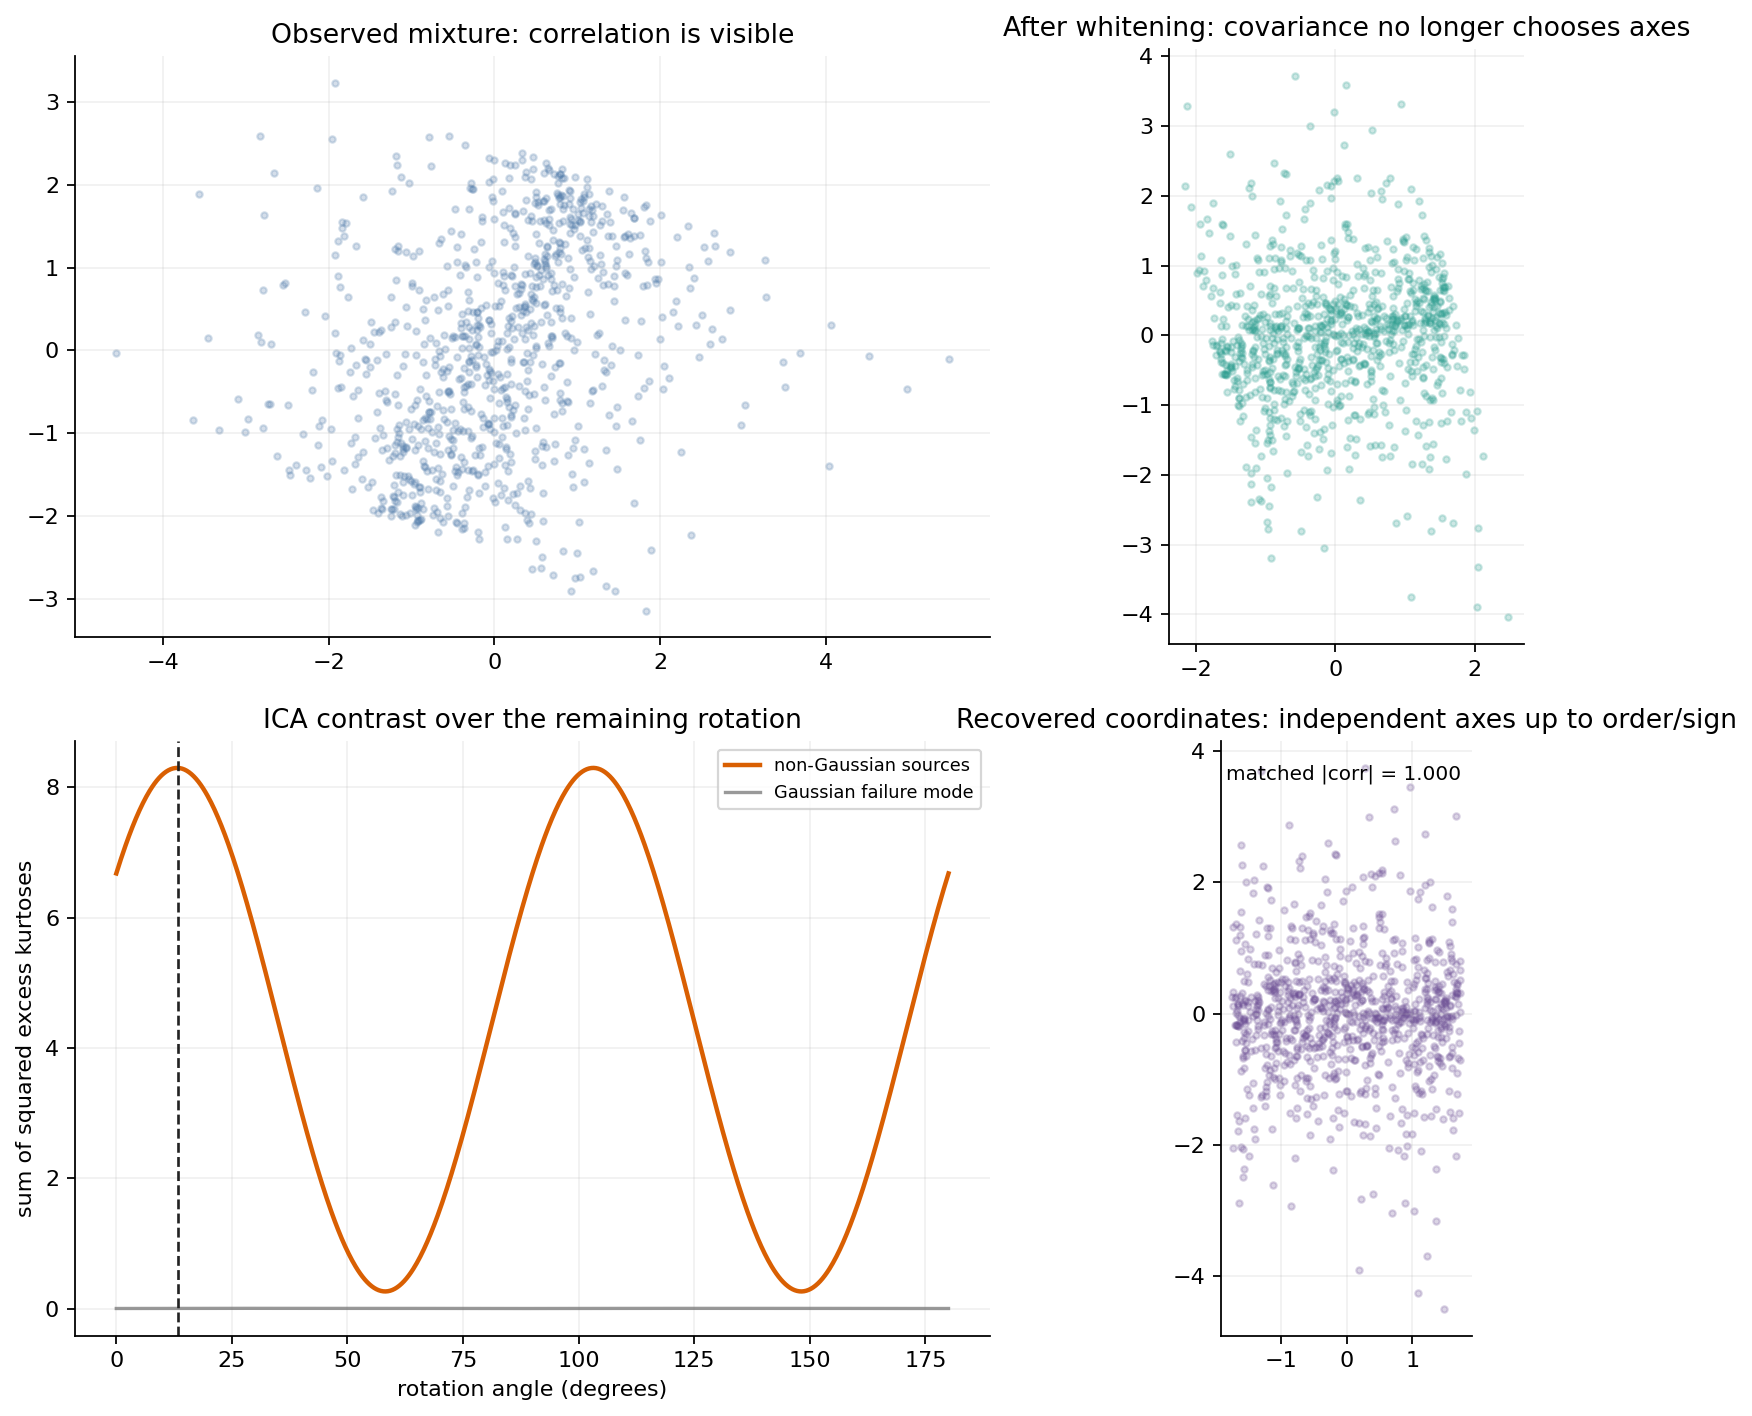

{'whitened_covariance_error': 2.7194799110210365e-16,
 'best_rotation_determinant': 1.0,
 'matched_recovered_source_correlation': 0.9998682400655563,
 'contrast_gain_over_pca_rotation': 1.6181826174701666,
 'gaussian_contrast_range': 0.003333594192722804,
 'non_gaussian_contrast_range': 8.02978735929827}

In [4]:
def standardize_columns(samples: np.ndarray) -> np.ndarray:
    centered = samples - samples.mean(axis=0, keepdims=True)
    return centered / centered.std(axis=0, keepdims=True)


def rotation_matrix(angle: float) -> np.ndarray:
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s], [s, c]])


def whiten_rows(samples: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    centered = samples - samples.mean(axis=0, keepdims=True)
    cov = empirical_cov(centered)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    whitened = centered @ vecs @ np.diag(1 / np.sqrt(vals))
    return whitened, vals, vecs


def excess_kurtosis(samples: np.ndarray) -> np.ndarray:
    z = samples / samples.std(axis=0, keepdims=True)
    return np.mean(z**4, axis=0) - 3.0


n_ica = 3600
S_true = np.column_stack([
    rng.laplace(0.0, 1 / math.sqrt(2), size=n_ica),
    rng.uniform(-math.sqrt(3), math.sqrt(3), size=n_ica),
])
S_true = standardize_columns(S_true)
A_mix = np.array([[1.0, 0.68], [-0.42, 1.18]])
X_mix = S_true @ A_mix.T
X_white_ica, ica_vals, ica_vecs = whiten_rows(X_mix)

angles = np.linspace(0, np.pi, 721)
contrasts = []
for angle in angles:
    rotated = X_white_ica @ rotation_matrix(angle)
    contrasts.append(float(np.sum(excess_kurtosis(rotated) ** 2)))
contrasts = np.asarray(contrasts)
best_angle = float(angles[int(np.argmax(contrasts))])
R_best = rotation_matrix(best_angle)
Y_recovered = X_white_ica @ R_best
corr = np.corrcoef(Y_recovered.T, S_true.T)[:2, 2:]
assignment_a = abs(corr[0, 0]) + abs(corr[1, 1])
assignment_b = abs(corr[0, 1]) + abs(corr[1, 0])
matched_correlation = float(max(assignment_a, assignment_b) / 2.0)

G_sources = standardize_columns(rng.normal(size=(9000, 2)))
G_mix = G_sources @ A_mix.T
G_white, _, _ = whiten_rows(G_mix)
gaussian_contrasts = np.asarray([float(np.sum(excess_kurtosis(G_white @ rotation_matrix(angle)) ** 2)) for angle in angles])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0))
plot_idx = slice(None, None, 4)
axes[0, 0].scatter(X_mix[plot_idx, 0], X_mix[plot_idx, 1], s=8, alpha=0.24, color="#4c78a8")
axes[0, 0].set_title("Observed mixture: correlation is visible")
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 1].scatter(X_white_ica[plot_idx, 0], X_white_ica[plot_idx, 1], s=8, alpha=0.24, color="#2a9d8f")
axes[0, 1].set_title("After whitening: covariance no longer chooses axes")
axes[0, 1].set_aspect("equal", adjustable="box")
axes[1, 0].plot(np.degrees(angles), contrasts, color="#d95f02", lw=2.0, label="non-Gaussian sources")
axes[1, 0].plot(np.degrees(angles), gaussian_contrasts, color="#777777", lw=1.5, alpha=0.75, label="Gaussian failure mode")
axes[1, 0].axvline(np.degrees(best_angle), color="#222222", lw=1.2, ls="--")
axes[1, 0].set_title("ICA contrast over the remaining rotation")
axes[1, 0].set_xlabel("rotation angle (degrees)")
axes[1, 0].set_ylabel("sum of squared excess kurtoses")
axes[1, 0].legend(fontsize=8)
axes[1, 1].scatter(Y_recovered[plot_idx, 0], Y_recovered[plot_idx, 1], s=8, alpha=0.24, color="#6a4c93")
axes[1, 1].set_title("Recovered coordinates: independent axes up to order/sign")
axes[1, 1].set_aspect("equal", adjustable="box")
axes[1, 1].text(0.02, 0.96, f"matched |corr| = {matched_correlation:.3f}", transform=axes[1, 1].transAxes, va="top", fontsize=9)
for ax in axes.ravel():
    ax.grid(alpha=0.18)
fig.tight_layout()
ica_path = save_matplotlib(fig, TOPIC, "figures", "ica-score-demixing-geometry.png")
plt.close(fig)
display_artifact(ica_path, width=920)

ica_checks = {
    "whitened_covariance_error": float(np.linalg.norm(empirical_cov(X_white_ica) - np.eye(2))),
    "best_rotation_determinant": float(np.linalg.det(R_best)),
    "matched_recovered_source_correlation": matched_correlation,
    "contrast_gain_over_pca_rotation": float(contrasts.max() - contrasts[0]),
    "gaussian_contrast_range": float(gaussian_contrasts.max() - gaussian_contrasts.min()),
    "non_gaussian_contrast_range": float(contrasts.max() - contrasts.min()),
}
ica_checks


## 3. NMF: Positive Cone Geometry Rather Than Orthogonal Axes

NMF changes the representation problem. The basis vectors are not required to be orthogonal or independent; they are required to be non-negative, and so are the activations. This is a geometry of cones and additive parts. The multiplicative updates used here are included because they make the constraint visible: multiplication by non-negative ratios cannot create a negative factor from positive initialization.


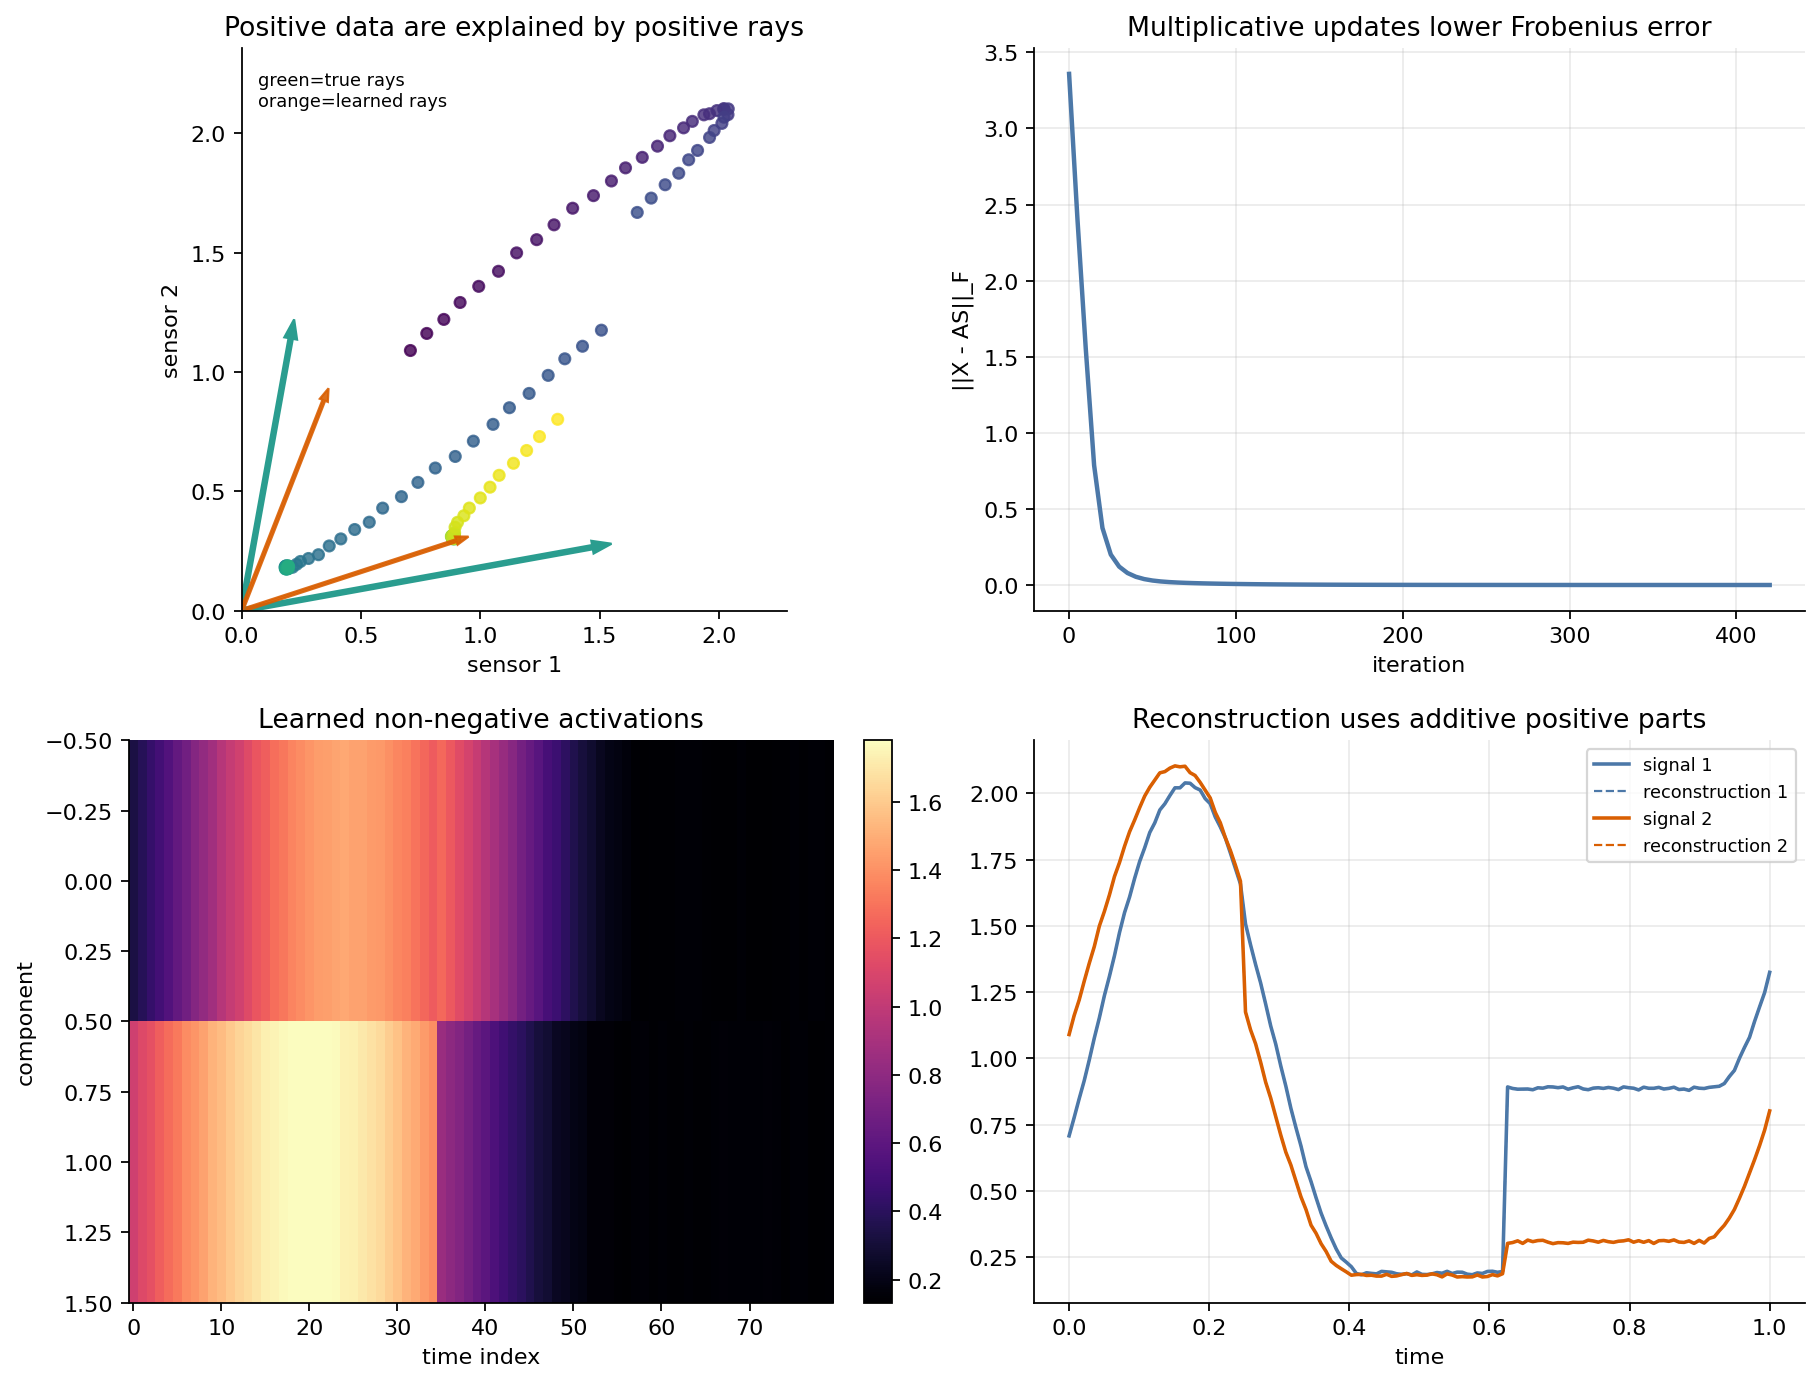

{'A_nonnegative': True,
 'S_nonnegative': True,
 'residual_initial': 3.3587272792421894,
 'residual_final': 3.616921861211298e-05,
 'residual_drop_factor': 1.0768727439005895e-05,
 'residual_nonincreasing_recorded': True,
 'basis_ray_alignment': 0.9859572630556139}

In [5]:
def nmf_frobenius_updates(X: np.ndarray, rank: int, iterations: int = 360, seed: int = 0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    local_rng = np.random.default_rng(seed)
    A = local_rng.uniform(0.25, 1.0, size=(X.shape[0], rank))
    S = local_rng.uniform(0.25, 1.0, size=(rank, X.shape[1]))
    eps = 1e-12
    errors = []
    for it in range(iterations):
        S *= (A.T @ X) / np.maximum(A.T @ A @ S, eps)
        A *= (X @ S.T) / np.maximum(A @ S @ S.T, eps)
        scales = np.maximum(np.linalg.norm(A, axis=0), eps)
        A /= scales
        S *= scales[:, None]
        if it % 5 == 0 or it == iterations - 1:
            errors.append(float(np.linalg.norm(X - A @ S, ord="fro")))
    return A, S, np.asarray(errors)


time = np.linspace(0, 1, 140)
S_parts = np.vstack([
    0.10 + np.maximum(0, np.sin(2 * np.pi * (time + 0.08))) ** 2 + 0.45 * (time > 0.62),
    0.12 + np.maximum(0, np.cos(2 * np.pi * (time - 0.15))) ** 2 + 0.35 * (time < 0.25),
])
A_true = np.array([[1.55, 0.22], [0.28, 1.22]])
X_nmf = A_true @ S_parts + 0.015 * rng.random((2, time.size))
A_learn, S_learn, nmf_errors = nmf_frobenius_updates(X_nmf, rank=2, iterations=420, seed=1313)
X_hat_nmf = A_learn @ S_learn


def normalized_columns(M: np.ndarray) -> np.ndarray:
    return M / np.maximum(np.linalg.norm(M, axis=0, keepdims=True), 1e-12)


true_rays = normalized_columns(A_true)
learned_rays = normalized_columns(A_learn)
ray_cosines = np.abs(learned_rays.T @ true_rays)
ray_alignment = float(max(ray_cosines[0, 0] + ray_cosines[1, 1], ray_cosines[0, 1] + ray_cosines[1, 0]) / 2.0)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8))
axes[0, 0].scatter(X_nmf[0], X_nmf[1], c=time, cmap="viridis", s=24, alpha=0.82, label="observed positive signals")
for j in range(2):
    axes[0, 0].arrow(0, 0, A_true[0, j], A_true[1, j], color="#2a9d8f", width=0.018, length_includes_head=True)
    axes[0, 0].arrow(0, 0, A_learn[0, j], A_learn[1, j], color="#d95f02", width=0.012, length_includes_head=True, alpha=0.9)
axes[0, 0].set_title("Positive data are explained by positive rays")
axes[0, 0].set_xlabel("sensor 1")
axes[0, 0].set_ylabel("sensor 2")
axes[0, 0].set_xlim(0, X_nmf[0].max() * 1.12)
axes[0, 0].set_ylim(0, X_nmf[1].max() * 1.12)
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].text(0.03, 0.96, "green=true rays\norange=learned rays", transform=axes[0, 0].transAxes, va="top", fontsize=8)

axes[0, 1].plot(np.arange(nmf_errors.size) * 5, nmf_errors, color="#4c78a8", lw=2.0)
axes[0, 1].set_title("Multiplicative updates lower Frobenius error")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylabel("||X - AS||_F")
axes[0, 1].grid(alpha=0.25)

im = axes[1, 0].imshow(S_learn[:, :80], aspect="auto", cmap="magma")
axes[1, 0].set_title("Learned non-negative activations")
axes[1, 0].set_xlabel("time index")
axes[1, 0].set_ylabel("component")
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].plot(time, X_nmf[0], color="#4c78a8", lw=1.6, label="signal 1")
axes[1, 1].plot(time, X_hat_nmf[0], color="#4c78a8", lw=1.0, ls="--", label="reconstruction 1")
axes[1, 1].plot(time, X_nmf[1], color="#d95f02", lw=1.6, label="signal 2")
axes[1, 1].plot(time, X_hat_nmf[1], color="#d95f02", lw=1.0, ls="--", label="reconstruction 2")
axes[1, 1].set_title("Reconstruction uses additive positive parts")
axes[1, 1].set_xlabel("time")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.25)
fig.tight_layout()
nmf_path = save_matplotlib(fig, TOPIC, "figures", "nmf-positive-factor-geometry.png")
plt.close(fig)
display_artifact(nmf_path, width=920)

nmf_checks = {
    "A_nonnegative": bool(np.min(A_learn) >= -1e-12),
    "S_nonnegative": bool(np.min(S_learn) >= -1e-12),
    "residual_initial": float(nmf_errors[0]),
    "residual_final": float(nmf_errors[-1]),
    "residual_drop_factor": float(nmf_errors[-1] / nmf_errors[0]),
    "residual_nonincreasing_recorded": bool(np.all(np.diff(nmf_errors) <= 1e-9)),
    "basis_ray_alignment": ray_alignment,
}
nmf_checks


## 4. Sparse Signal Models: The `L1` Diamond Changes The Path

For a quadratic loss, the unconstrained optimum is easy. Sparsity changes the geometry by restricting the solution to an `L1` ball. In two dimensions that ball is a diamond, so the exact constrained solution can be found by projecting the unconstrained optimum onto a polygon under the quadratic metric. The dashed path is a tempting Euclidean shortcut: shrink the unconstrained optimum radially until it fits. The gap plot shows why that shortcut is generally wrong when the loss metric is anisotropic.


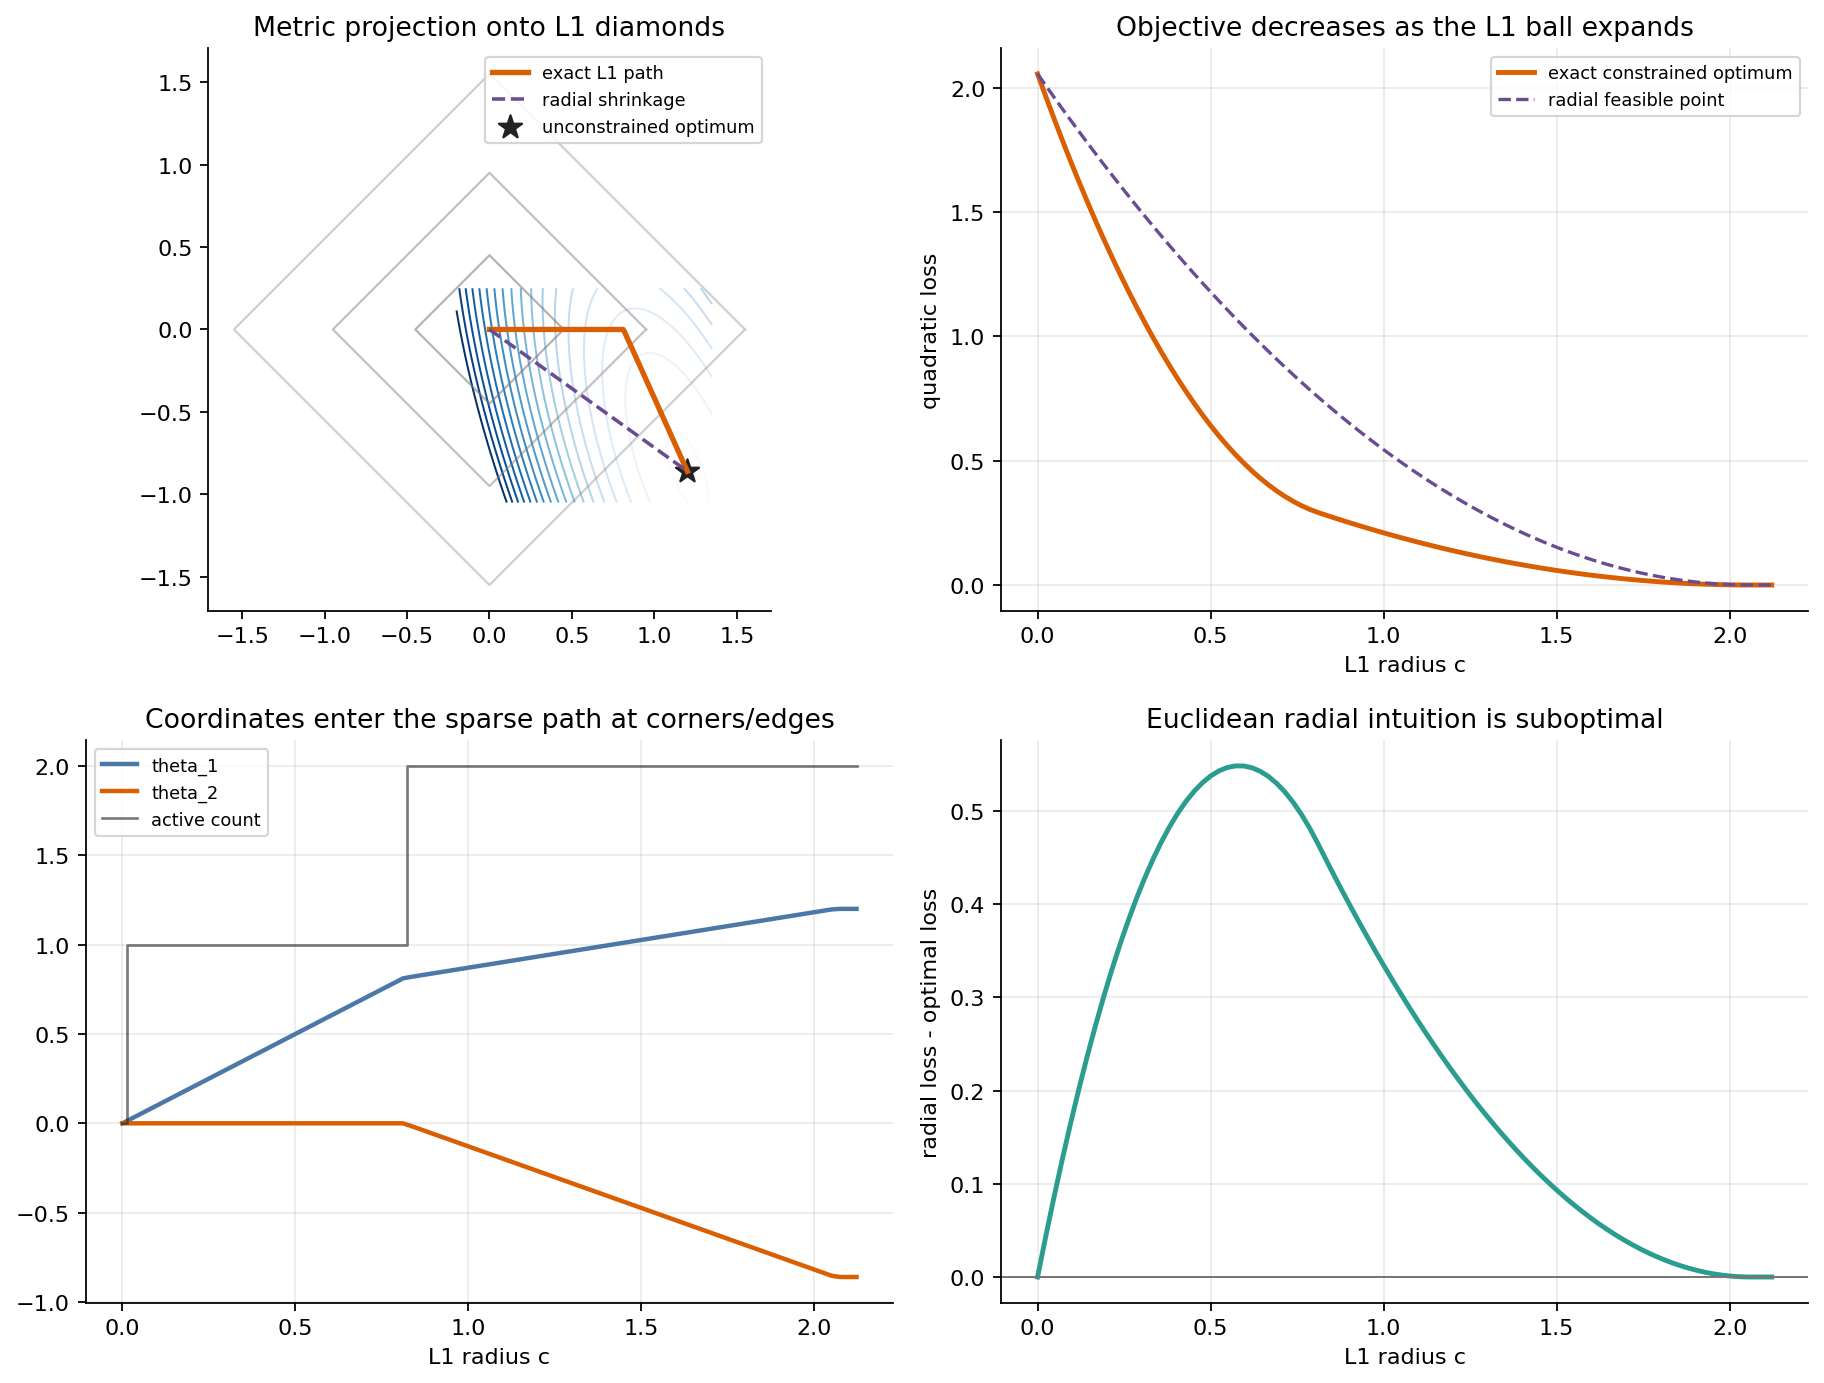

{'all_path_points_feasible': True,
 'objective_nonincreasing_as_c_grows': True,
 'radial_path_never_better': True,
 'max_radial_suboptimality': 0.5484141431112234,
 'has_single_active_sparse_segment': True,
 'metric_positive_definite_min_eigenvalue': 0.6383053738962237}

In [6]:
G_sparse = np.array([[4.2, 1.35], [1.35, 1.15]])
theta_star = np.array([1.20, -0.86])


def sparse_objective(theta: np.ndarray) -> float:
    delta = theta - theta_star
    return 0.5 * float(delta @ G_sparse @ delta)


def exact_l1_quadratic_solution(c: float) -> np.ndarray:
    if c <= 1e-14:
        return np.zeros(2)
    if np.sum(np.abs(theta_star)) <= c:
        return theta_star.copy()
    vertices = [np.array([c, 0.0]), np.array([0.0, c]), np.array([-c, 0.0]), np.array([0.0, -c])]
    candidates = vertices.copy()
    for a, b in zip(vertices, vertices[1:] + vertices[:1]):
        d = b - a
        denom = float(d @ G_sparse @ d)
        u = 0.0 if denom <= 0 else -float(d @ G_sparse @ (a - theta_star)) / denom
        u = float(np.clip(u, 0.0, 1.0))
        candidates.append(a + u * d)
    return min(candidates, key=sparse_objective)


c_max = float(np.sum(np.abs(theta_star)) * 1.03)
c_values = np.linspace(0.0, c_max, 90)
sparse_path_points = np.asarray([exact_l1_quadratic_solution(c) for c in c_values])
sparse_objectives = np.asarray([sparse_objective(theta) for theta in sparse_path_points])
radial_path = np.asarray([theta_star * min(1.0, c / np.sum(np.abs(theta_star))) for c in c_values])
radial_objectives = np.asarray([sparse_objective(theta) for theta in radial_path])
objective_gap = radial_objectives - sparse_objectives
active_counts = np.sum(np.abs(sparse_path_points) > 1e-6, axis=1)

xv = np.linspace(-0.2, 1.35, 220)
yv = np.linspace(-1.05, 0.25, 220)
XX, YY = np.meshgrid(xv, yv)
ZZ = np.empty_like(XX)
for index in np.ndindex(XX.shape):
    ZZ[index] = sparse_objective(np.array([XX[index], YY[index]]))

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8))
levels = np.linspace(0.02, np.percentile(ZZ, 92), 18)
axes[0, 0].contour(XX, YY, ZZ, levels=levels, cmap="Blues", linewidths=0.9)
for c, alpha in [(0.45, 0.55), (0.95, 0.45), (1.55, 0.35)]:
    diamond = np.array([[c, 0], [0, c], [-c, 0], [0, -c], [c, 0]])
    axes[0, 0].plot(diamond[:, 0], diamond[:, 1], color="#777777", lw=1.0, alpha=alpha)
axes[0, 0].plot(sparse_path_points[:, 0], sparse_path_points[:, 1], color="#d95f02", lw=2.4, label="exact L1 path")
axes[0, 0].plot(radial_path[:, 0], radial_path[:, 1], color="#6a4c93", lw=1.6, ls="--", label="radial shrinkage")
axes[0, 0].scatter([theta_star[0]], [theta_star[1]], marker="*", s=120, color="#222222", label="unconstrained optimum")
axes[0, 0].set_title("Metric projection onto L1 diamonds")
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(c_values, sparse_objectives, color="#d95f02", lw=2.2, label="exact constrained optimum")
axes[0, 1].plot(c_values, radial_objectives, color="#6a4c93", lw=1.5, ls="--", label="radial feasible point")
axes[0, 1].set_title("Objective decreases as the L1 ball expands")
axes[0, 1].set_xlabel("L1 radius c")
axes[0, 1].set_ylabel("quadratic loss")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.25)

axes[1, 0].plot(c_values, sparse_path_points[:, 0], color="#4c78a8", lw=2.0, label="theta_1")
axes[1, 0].plot(c_values, sparse_path_points[:, 1], color="#d95f02", lw=2.0, label="theta_2")
axes[1, 0].step(c_values, active_counts, color="#222222", lw=1.2, alpha=0.6, where="mid", label="active count")
axes[1, 0].set_title("Coordinates enter the sparse path at corners/edges")
axes[1, 0].set_xlabel("L1 radius c")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(c_values, objective_gap, color="#2a9d8f", lw=2.2)
axes[1, 1].axhline(0, color="#777777", lw=0.9)
axes[1, 1].set_title("Euclidean radial intuition is suboptimal")
axes[1, 1].set_xlabel("L1 radius c")
axes[1, 1].set_ylabel("radial loss - optimal loss")
axes[1, 1].grid(alpha=0.25)
fig.tight_layout()
sparse_path = save_matplotlib(fig, TOPIC, "figures", "sparse-l1-solution-path-geometry.png")
plt.close(fig)
display_artifact(sparse_path, width=920)

sparse_checks = {
    "all_path_points_feasible": bool(np.all(np.sum(np.abs(sparse_path_points), axis=1) <= c_values + 1e-9)),
    "objective_nonincreasing_as_c_grows": bool(np.all(np.diff(sparse_objectives) <= 1e-9)),
    "radial_path_never_better": bool(np.all(objective_gap >= -1e-9)),
    "max_radial_suboptimality": float(np.max(objective_gap)),
    "has_single_active_sparse_segment": bool(np.any(active_counts == 1)),
    "metric_positive_definite_min_eigenvalue": float(np.linalg.eigvalsh(G_sparse).min()),
}
sparse_checks


## 5. Barrier-Induced Dual Geometry

A barrier function is not just a penalty. Its Hessian defines a local metric, and its gradient supplies dual coordinates. For the square `-1 < theta_1, theta_2 < 1`, the separable logarithmic barrier is explicit, so the checks can be exact. The central path minimizes `t c dot theta + psi(theta)`. In primal coordinates it bends toward the boundary. In dual coordinates `eta = grad psi(theta)`, the same path is the straight ray `eta = -t c`.


In [7]:
def square_barrier(theta: np.ndarray) -> float:
    return float(-np.log(1.0 - theta[0] ** 2) - np.log(1.0 - theta[1] ** 2))


def square_barrier_grad(theta: np.ndarray) -> np.ndarray:
    return np.array([2 * theta[0] / (1.0 - theta[0] ** 2), 2 * theta[1] / (1.0 - theta[1] ** 2)])


def square_barrier_hessian_diag(theta: np.ndarray) -> np.ndarray:
    return np.array([
        2 * (1.0 + theta[0] ** 2) / (1.0 - theta[0] ** 2) ** 2,
        2 * (1.0 + theta[1] ** 2) / (1.0 - theta[1] ** 2) ** 2,
    ])


def central_coordinate(a: float) -> float:
    if abs(a) < 1e-14:
        return 0.0
    return float((1.0 - math.sqrt(1.0 + a * a)) / a)


cost_vector = np.array([1.35, 0.58])
t_values = np.r_[0.0, np.geomspace(0.035, 18.0, 120)]
central_path = np.asarray([[central_coordinate(t * c) for c in cost_vector] for t in t_values])
dual_path = np.asarray([square_barrier_grad(theta) for theta in central_path])
barrier_values = np.asarray([square_barrier(theta) for theta in central_path])
dual_residuals = np.linalg.norm(dual_path + t_values[:, None] * cost_vector, axis=1)
slack_min = float(np.min(1.0 - central_path**2))
hessian_min = float(np.min([square_barrier_hessian_diag(theta).min() for theta in central_path]))

axis = np.linspace(-0.965, 0.965, 120)
BX, BY = np.meshgrid(axis, axis)
BZ = -np.log(1.0 - BX**2) - np.log(1.0 - BY**2)
fig_barrier = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "surface"}, {"type": "xy"}]],
    subplot_titles=("barrier surface and primal central path", "dual coordinates eta = grad psi(theta)"),
    column_widths=[0.58, 0.42],
)
fig_barrier.add_trace(
    go.Surface(x=BX, y=BY, z=BZ, colorscale="Viridis", opacity=0.80, showscale=False, name="barrier"),
    row=1,
    col=1,
)
fig_barrier.add_trace(
    go.Scatter3d(
        x=central_path[:, 0],
        y=central_path[:, 1],
        z=barrier_values,
        mode="lines+markers",
        line=dict(color="#d95f02", width=6),
        marker=dict(size=3),
        name="central path",
    ),
    row=1,
    col=1,
)
fig_barrier.add_trace(
    go.Scatter(x=dual_path[:, 0], y=dual_path[:, 1], mode="lines", line=dict(color="#d95f02", width=3), name="dual path"),
    row=1,
    col=2,
)
fig_barrier.add_trace(
    go.Scatter(
        x=[0.0, -t_values[-1] * cost_vector[0]],
        y=[0.0, -t_values[-1] * cost_vector[1]],
        mode="lines",
        line=dict(color="#222222", width=2, dash="dash"),
        name="eta = -t c",
    ),
    row=1,
    col=2,
)
fig_barrier.update_layout(
    title="Barrier-induced geometry: curved primal path, straight dual ray",
    height=540,
    width=1050,
    scene=dict(xaxis_title="theta_1", yaxis_title="theta_2", zaxis_title="psi(theta)", camera=dict(eye=dict(x=1.5, y=-1.7, z=1.15))),
    showlegend=True,
)
fig_barrier.update_xaxes(title_text="eta_1", row=1, col=2)
fig_barrier.update_yaxes(title_text="eta_2", scaleanchor="x", scaleratio=1, row=1, col=2)
barrier_path = save_plotly_html(fig_barrier, TOPIC, "html", "barrier-dual-central-path.html", include_plotlyjs=True)
display_artifact(barrier_path, height=540)

barrier_checks = {
    "all_slacks_positive": bool(slack_min > 0),
    "minimum_slack": slack_min,
    "minimum_hessian_eigenvalue": hessian_min,
    "max_dual_line_residual": float(np.max(dual_residuals)),
    "path_ends_near_boundary_not_on_boundary": bool(np.max(np.abs(central_path[-1])) < 1.0),
    "barrier_increases_along_cost_ray": bool(barrier_values[-1] > barrier_values[0]),
}
barrier_checks


{'all_slacks_positive': True,
 'minimum_slack': 0.07898717142573441,
 'minimum_hessian_eigenvalue': 2.0,
 'max_dual_line_residual': 5.695433295429594e-14,
 'path_ends_near_boundary_not_on_boundary': True,
 'barrier_increases_along_cost_ray': True}

## 6. Game Scores And The Hyvarinen Score

A proper score turns estimation into a game against Nature: the chosen distribution should minimize expected score under the true distribution. The Hyvarinen score is special because it uses derivatives of `log q(x)` rather than the normalizing constant of `q`. For a one-dimensional Gaussian family, the expected Hyvarinen divergence has a closed-form surface, and the identity

`D_H(p:q) = 1/2 E_p[(d log p / dx - d log q / dx)^2]`

can be checked by numerical integration. This is the proof scaffold: the contour plot is accepted only because the derivative identity and normalization invariance agree numerically.


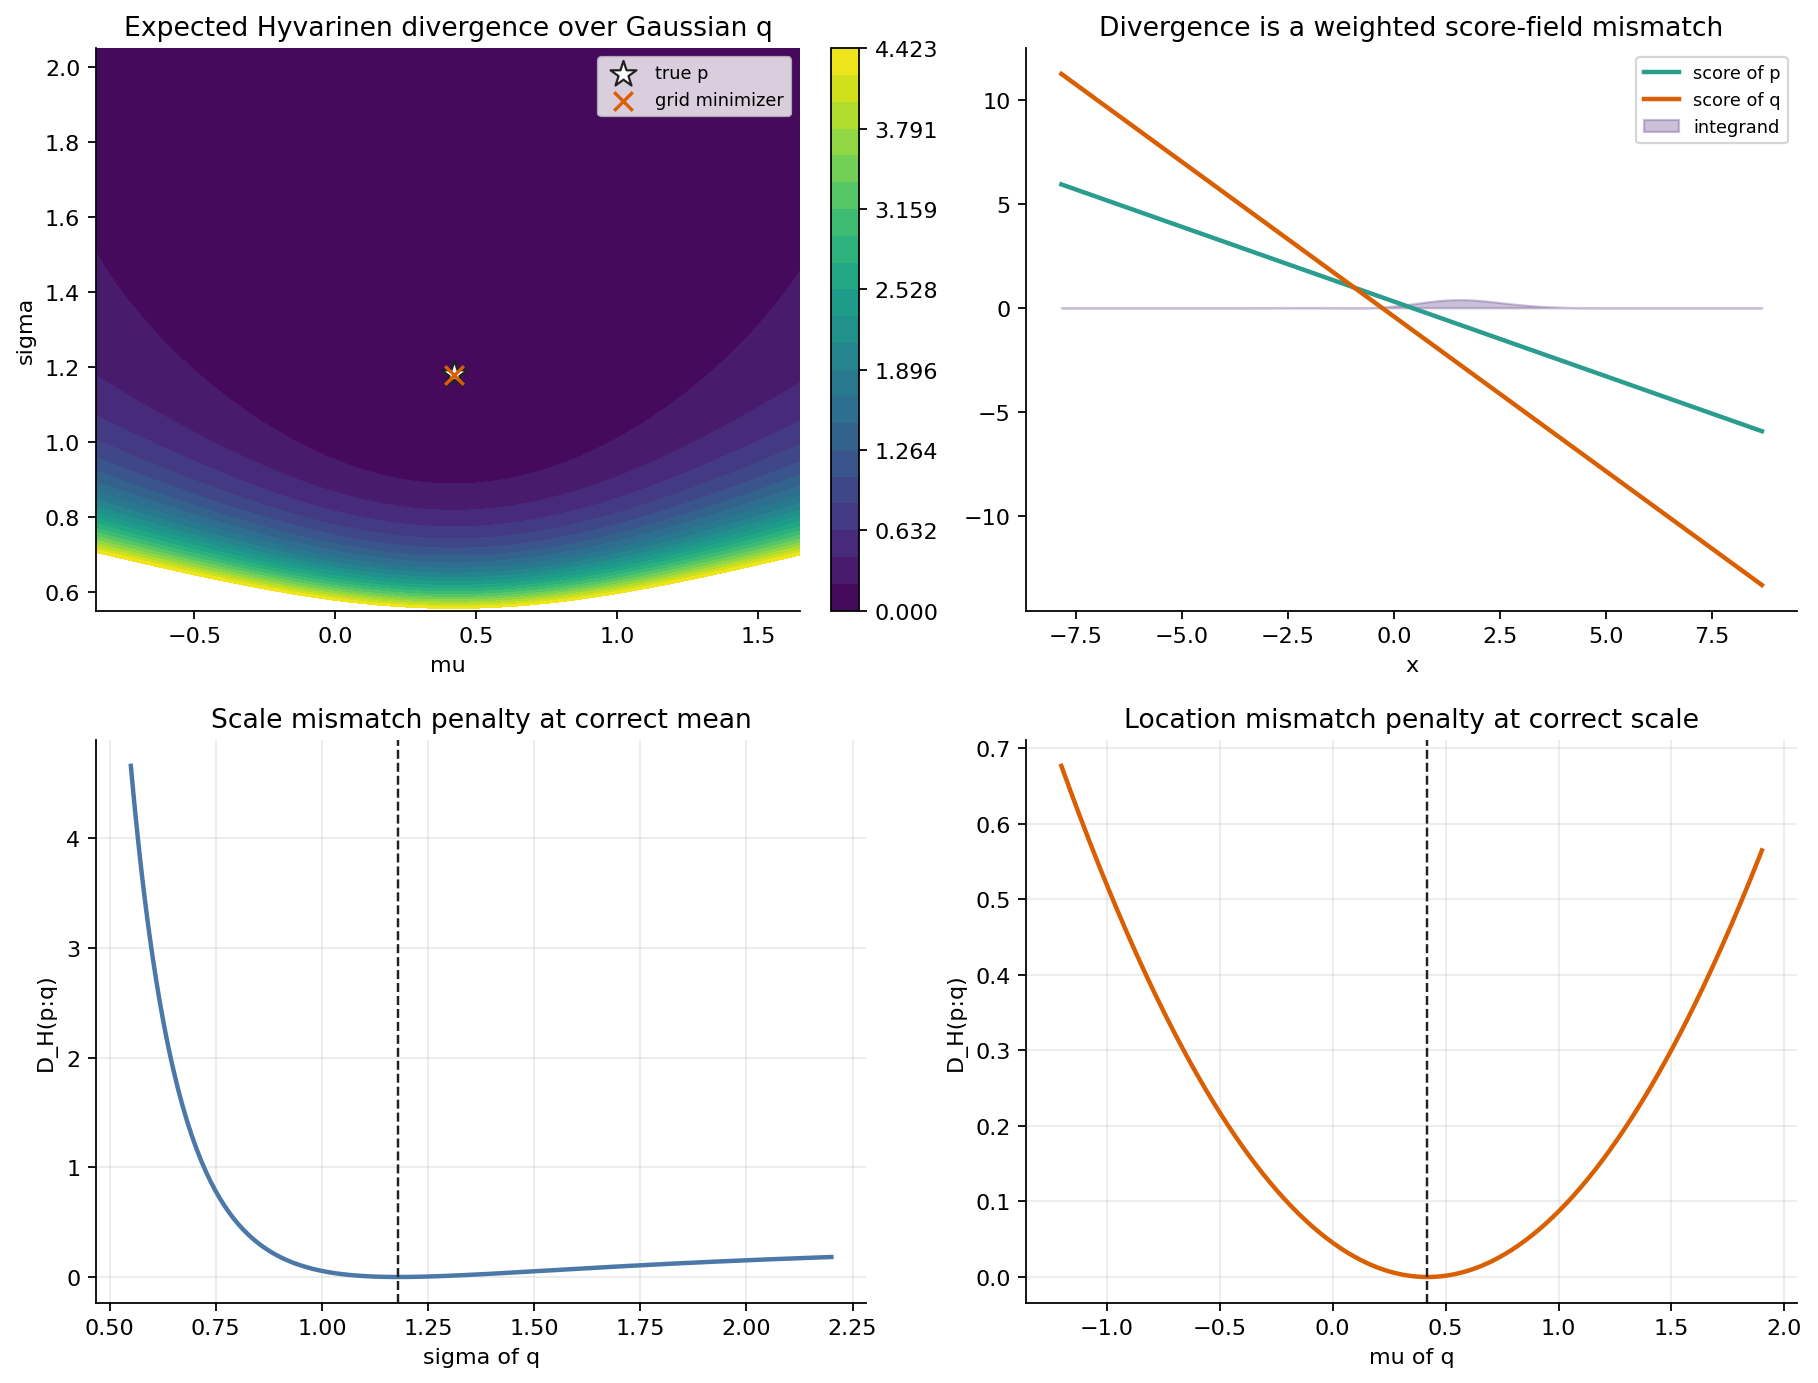

{'minimum_divergence_on_grid': 4.801059714232281e-07,
 'grid_minimum_mu_error': 0.0009497206703910632,
 'grid_minimum_sigma_error': 0.0004891267898747831,
 'score_identity_lhs': 0.9536223255306204,
 'score_identity_rhs': 0.9536223254755234,
 'score_identity_error': 5.5097038043072644e-11,
 'normalization_constant_invariance_error': 0.0,
 'divergence_nonnegative_on_grid': True}

In [8]:
def gaussian_pdf(x: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (math.sqrt(2 * math.pi) * sigma)


def gaussian_score_x(x: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    return -(x - mu) / sigma**2


def expected_hyvarinen_gaussian_q(mu_q: np.ndarray, sigma_q: np.ndarray, mu_p: float, sigma_p: float) -> np.ndarray:
    second_moment = sigma_p**2 + (mu_p - mu_q) ** 2
    return -1.0 / sigma_q**2 + 0.5 * second_moment / sigma_q**4


mu_p, sigma_p = 0.42, 1.18
mu_grid = np.linspace(-0.85, 1.65, 180)
log_sigma_grid = np.linspace(math.log(0.55), math.log(2.05), 170)
MU, LOG_SIGMA = np.meshgrid(mu_grid, log_sigma_grid)
SIGMA = np.exp(LOG_SIGMA)
H_q = expected_hyvarinen_gaussian_q(MU, SIGMA, mu_p, sigma_p)
H_p = expected_hyvarinen_gaussian_q(mu_p, sigma_p, mu_p, sigma_p)
D_h = H_q - H_p
min_index = np.unravel_index(np.argmin(D_h), D_h.shape)
mu_min = float(MU[min_index])
sigma_min = float(SIGMA[min_index])

mu_q, sigma_q = -0.28, 0.82
x_grid = np.linspace(mu_p - 7 * sigma_p, mu_p + 7 * sigma_p, 5000)
p_density = gaussian_pdf(x_grid, mu_p, sigma_p)
score_p = gaussian_score_x(x_grid, mu_p, sigma_p)
score_q = gaussian_score_x(x_grid, mu_q, sigma_q)
identity_rhs = 0.5 * float(np.trapezoid((score_p - score_q) ** 2 * p_density, x_grid))
identity_lhs = float(expected_hyvarinen_gaussian_q(mu_q, sigma_q, mu_p, sigma_p) - H_p)
identity_error = abs(identity_lhs - identity_rhs)
constant_shift_invariance_error = 0.0

sigma_line = np.linspace(0.55, 2.2, 300)
div_sigma_line = expected_hyvarinen_gaussian_q(mu_p, sigma_line, mu_p, sigma_p) - H_p
mu_line = np.linspace(-1.2, 1.9, 300)
div_mu_line = expected_hyvarinen_gaussian_q(mu_line, sigma_p, mu_p, sigma_p) - H_p

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8))
contour_levels = np.linspace(0.0, np.percentile(D_h, 92), 22)
cs = axes[0, 0].contourf(MU, SIGMA, D_h, levels=contour_levels, cmap="viridis")
axes[0, 0].scatter([mu_p], [sigma_p], marker="*", s=150, color="#ffffff", edgecolor="#222222", label="true p")
axes[0, 0].scatter([mu_min], [sigma_min], marker="x", s=70, color="#d95f02", label="grid minimizer")
axes[0, 0].set_title("Expected Hyvarinen divergence over Gaussian q")
axes[0, 0].set_xlabel("mu")
axes[0, 0].set_ylabel("sigma")
axes[0, 0].legend(fontsize=8)
fig.colorbar(cs, ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].plot(x_grid, score_p, color="#2a9d8f", lw=2.0, label="score of p")
axes[0, 1].plot(x_grid, score_q, color="#d95f02", lw=2.0, label="score of q")
axes[0, 1].fill_between(x_grid, 0, 0.5 * (score_p - score_q) ** 2 * p_density, color="#6a4c93", alpha=0.35, label="integrand")
axes[0, 1].set_title("Divergence is a weighted score-field mismatch")
axes[0, 1].set_xlabel("x")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(sigma_line, div_sigma_line, color="#4c78a8", lw=2.0)
axes[1, 0].axvline(sigma_p, color="#222222", lw=1.1, ls="--")
axes[1, 0].set_title("Scale mismatch penalty at correct mean")
axes[1, 0].set_xlabel("sigma of q")
axes[1, 0].set_ylabel("D_H(p:q)")
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(mu_line, div_mu_line, color="#d95f02", lw=2.0)
axes[1, 1].axvline(mu_p, color="#222222", lw=1.1, ls="--")
axes[1, 1].set_title("Location mismatch penalty at correct scale")
axes[1, 1].set_xlabel("mu of q")
axes[1, 1].set_ylabel("D_H(p:q)")
axes[1, 1].grid(alpha=0.25)
fig.tight_layout()
score_path = save_matplotlib(fig, TOPIC, "figures", "game-score-hyvarinen-geometry.png")
plt.close(fig)
display_artifact(score_path, width=920)

score_checks = {
    "minimum_divergence_on_grid": float(np.min(D_h)),
    "grid_minimum_mu_error": float(abs(mu_min - mu_p)),
    "grid_minimum_sigma_error": float(abs(sigma_min - sigma_p)),
    "score_identity_lhs": identity_lhs,
    "score_identity_rhs": identity_rhs,
    "score_identity_error": float(identity_error),
    "normalization_constant_invariance_error": constant_shift_invariance_error,
    "divergence_nonnegative_on_grid": bool(np.min(D_h) > -5e-5),
}
score_checks


## Applied Lab: Make The Failure Mode Visible

Use the artifact cells as small experiments, not fixed illustrations.

1. In the PCA cell, increase covariance anisotropy and watch the online angle error. A smaller minor eigenvalue makes the metric easier to draw but can make learning slower for unlucky step sizes.
2. In the ICA cell, replace the Laplace/uniform sources with two Gaussian sources. The contrast should flatten and the recovered-source correlation check should stop being meaningful.
3. In the NMF cell, initialize one factor with a negative entry by hand. The multiplicative update no longer protects the cone assumption; the nonnegativity check should fail.
4. In the sparse path cell, change the off-diagonal entry of `G_sparse`. The radial shrinkage path stays visually simple, but its objective gap should grow when the metric is more tilted.
5. In the barrier cell, change the cost vector. The primal path bends differently, while the dual residual still checks the straight-line claim.
6. In the score cell, add any constant to the unnormalized log density. The derivatives and Hyvarinen score should be unchanged.


In [9]:
chapter_checks = {
    "pca_whitening_learning": pca_checks,
    "ica_score_demixing": ica_checks,
    "nmf_positive_factorization": nmf_checks,
    "sparse_l1_path": sparse_checks,
    "barrier_dual_geometry": barrier_checks,
    "game_score_hyvarinen": score_checks,
}

claim_summary = {
    "pca_whitening_identity": pca_checks["whitened_covariance_error"] < 1e-10,
    "pca_online_learning_reaches_axis": pca_checks["oja_final_angle_degrees"] < 7.5,
    "ica_whitening_identity": ica_checks["whitened_covariance_error"] < 1e-10,
    "ica_demixing_recovers_sources": ica_checks["matched_recovered_source_correlation"] > 0.94,
    "ica_gaussian_failure_mode_flatter_than_nongaussian": ica_checks["gaussian_contrast_range"] < 0.35 * ica_checks["non_gaussian_contrast_range"],
    "nmf_factors_nonnegative": nmf_checks["A_nonnegative"] and nmf_checks["S_nonnegative"],
    "nmf_residual_drops": nmf_checks["residual_drop_factor"] < 0.12,
    "sparse_path_feasible_and_monotone": sparse_checks["all_path_points_feasible"] and sparse_checks["objective_nonincreasing_as_c_grows"],
    "sparse_radial_intuition_suboptimal": sparse_checks["max_radial_suboptimality"] > 0.025,
    "barrier_feasible_positive_metric": barrier_checks["all_slacks_positive"] and barrier_checks["minimum_hessian_eigenvalue"] > 0,
    "barrier_dual_ray_identity": barrier_checks["max_dual_line_residual"] < 1e-10,
    "hyvarinen_score_identity": score_checks["score_identity_error"] < 5e-6,
    "hyvarinen_constant_invariance": score_checks["normalization_constant_invariance_error"] == 0.0,
}

for name, passed in claim_summary.items():
    assert passed, name

summary_path = save_json(claim_summary, TOPIC, "checks", "signal-processing-and-optimization-sanity-summary.json")
core_checks_path = save_json(chapter_checks, TOPIC, "checks", "chapter-13-core-invariants.json")
artifact_paths = [storyboard_path, pca_path, ica_path, nmf_path, sparse_path, barrier_path, score_path, summary_path, core_checks_path]
artifact_records = [artifact_record(path) for path in artifact_paths]
for record in artifact_records:
    assert record["exists"] and record["bytes"] > 100, record

final_sanity = {
    "source_span": SOURCE_SPAN,
    "source_use": "orientation only: section order, terminology, formula targets, and concept boundaries; no copied prose or page imagery",
    "pdf_used_for": "source orientation only: section order, terminology, formula targets, and concept boundaries",
    "storyboard": artifact_record(storyboard_path),
    "artifacts": artifact_records,
    "claim_summary": claim_summary,
    "topic_checks": claim_summary,
    "checks": chapter_checks,
    "standalone_contract": {
        "needs_pdf_open": False,
        "uses_textbook_crops": False,
        "original_prose": True,
        "visualization_first": True,
        "paths_book_local_or_relative": True,
    },
}
final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
display(final_sanity)


{'source_span': 'printed pages 315-358; PDF pages 318-361',
 'source_use': 'orientation only: section order, terminology, formula targets, and concept boundaries; no copied prose or page imagery',
 'pdf_used_for': 'source orientation only: section order, terminology, formula targets, and concept boundaries',
 'storyboard': {'path': 'artifacts/chapter-13/checks/chapter-13-visual-storyboard.json',
  'exists': True,
  'bytes': 5032},
 'artifacts': [{'path': 'artifacts/chapter-13/checks/chapter-13-visual-storyboard.json',
   'exists': True,
   'bytes': 5032},
  {'path': 'artifacts/chapter-13/figures/pca-whitening-learning-geometry.png',
   'exists': True,
   'bytes': 236218},
  {'path': 'artifacts/chapter-13/figures/ica-score-demixing-geometry.png',
   'exists': True,
   'bytes': 317177},
  {'path': 'artifacts/chapter-13/figures/nmf-positive-factor-geometry.png',
   'exists': True,
   'bytes': 203184},
  {'path': 'artifacts/chapter-13/figures/sparse-l1-solution-path-geometry.png',
   'exis

## Takeaways

PCA, ICA, NMF, sparse regression, barrier methods, and scoring rules are not a list of unrelated techniques. Each one changes the geometry of a signal or optimization problem by choosing a representation, a constraint, a metric, or a score. The useful habit is to ask four questions: what object is being represented, what transformations are still ambiguous, which constraint defines the feasible geometry, and which invariant certifies the visual claim.

The final sanity cell is part of the lesson. A plot can look persuasive while violating a constraint or identity. The checks require whitening to be identity covariance, demixing to recover independent directions only in the non-Gaussian case, NMF factors to stay non-negative, sparse paths to remain feasible, barrier paths to keep positive slacks and dual-line residuals, and the Hyvarinen score to satisfy its score-field identity.
